## LangGraph

A simple chat:

* Start node

* Chatbot

* End node

In [1]:
from collections.abc import Sequence
from dotenv import load_dotenv
from typing import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph

load_dotenv()

True

**Define a state**:

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage] # Type hint: expected data type for the value associated with the key

In [4]:
state = State(messages=[HumanMessage(content="Could you tell me a joke?")])

In [5]:
state.get("messages")[0].pretty_print()

================================ Human Message =================================

Could you tell me a joke?


**Define the chat Runnable**:

In [6]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=42,
    temperature=2,
    max_completion_tokens=500,
)

In [7]:
response = chat.invoke(state.get("messages"))

In [8]:
response.pretty_print()

================================== Ai Message ==================================

Why don’t scientists trust atoms?

Because they make up everything.


**Define the function in the chat node**:

In [9]:
def chatbot(state: State) -> State:

    print(f"----> Chatbot called:")

    response = chat.invoke(state.get("messages"))
    response.pretty_print()

    return State(messages=[response])

In [10]:
chatbot(state)

----> Chatbot called:
================================== Ai Message ==================================

Why don’t scientists trust atoms?

Because they make up everything.


{'messages': [AIMessage(content='Why don’t scientists trust atoms?\n\nBecause they make up everything.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DREqoRsOZBFFOjrbYPSg8wRsGHgwU', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d5d26-bfcc-7e71-8c4c-2243b566e818-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

**Build the graph**:

`StateGraph`:

* A graph whose nodes communicate by reading and writing to a shared state 

In [11]:
graph = StateGraph(state_schema=State)

In [12]:
graph.add_node("chatbot", chatbot)
graph.add_edge(start_key=START, end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key=END)

In [13]:
# Graph compilation
compiled_graph = graph.compile()
# Performs checks to ensure the graph is connected correctly
# Converst StateGraph into a CompiledStateGraph (a Runnable)

In [14]:
print("Is graph a Runnable?", isinstance(graph, Runnable))
print("Is compiled_graph a Runnable?", isinstance(compiled_graph, Runnable))

Is graph a Runnable? False
Is compiled_graph a Runnable? True


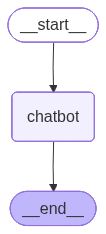

In [15]:
compiled_graph

**Test the Graph**:

In [16]:
compiled_graph.invoke(state)

----> Chatbot called:
================================== Ai Message ==================================

Why don’t scientists trust atoms?

Because they make up everything.


{'messages': [AIMessage(content='Why don’t scientists trust atoms?\n\nBecause they make up everything.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DREqxctWmePvtRBpnoyJcACZ7AfGK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d5d26-e0c5-76b1-afd0-c821aa4e6722-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

## Conditional Edges

* Start node

* Ask question

* Chatbot

* Ask another question:

    - If yes, prompt to the Ask question node

    - If no, end

* End node

In [46]:
from collections.abc import Sequence
from dotenv import load_dotenv
from typing import Literal, TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

State and chatbot:

In [47]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [48]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=354,
    temperature=0.5,
    max_completion_tokens=500,
)

In [49]:
def chatbot(state: State) -> State:

    print(f"----> Chatbot called:")

    response = chat.invoke(state.get("messages"))
    response.pretty_print()

    return State(messages=[response])

**Define Ask question and Ask another question nodes**:

Run the following functions only with the Graph `invoke()` method

In [50]:
# ask_question now uses interrupt(), so we test it through the graph instead
def ask_question(state: State) -> State:

    print("----> Ask question called:")

    question = interrupt("What is your question?")

    return State(messages=[HumanMessage(content=question)])

In [ ]:
# ask_another_question now uses interrupt(), so we test it through the graph instead
def ask_another_question(state: State) -> State:

    print("----> Ask another question called:")

    answer = interrupt("Would you like to ask another question (yes/no)?")

    return State(messages=[HumanMessage(content=answer)])

**Define a Routing function for the conditional edge**:

In [92]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:

    if state.get("messages")[-1].content == "yes":
        return "ask_question"
    else:
        return "__end__"

**Create the Graph**:

In [93]:
graph = StateGraph(state_schema=State)

In [94]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function
)

In [95]:
checkpointer = MemorySaver()
compiled_graph = graph.compile(checkpointer=checkpointer)

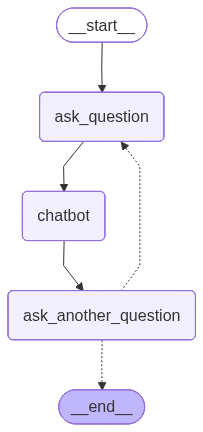

In [96]:
compiled_graph

We still need to fix the conditional edge:

* We use `path_map` key in the `add_conditional_edges()` method

In [97]:
graph = StateGraph(state_schema=State)

In [98]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
)

In [99]:
checkpointer = MemorySaver()
compiled_graph = graph.compile(checkpointer=checkpointer)

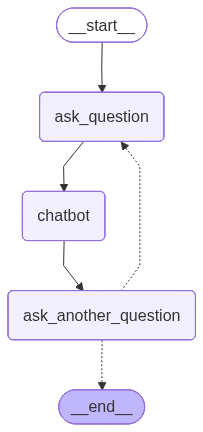

In [100]:
compiled_graph

In [101]:
print(compiled_graph.get_graph().draw_ascii())

          +-----------+       
          | __start__ |       
          +-----------+       
                 *            
                 *            
                 *            
         +--------------+     
         | ask_question |     
         +--------------+     
          ***         ..      
         *              ..    
       **                 ..  
+---------+                 . 
| chatbot |               ..  
+---------+             ..    
          ***         ..      
             *      ..        
              **   .          
     +----------------------+ 
     | ask_another_question | 
     +----------------------+ 
                 .            
                 .            
                 .            
            +---------+       
            | __end__ |       
            +---------+       


**Test the Graph**:

Using `interrupt()` as `input()` doesn't work here!

* Execute `.invoke()` with the given `config`

* Provide user inputs using `Command()`

In [102]:
config = {"configurable": {"thread_id": "1"}}

# First invoke: graph pauses at ask_question interrupt
result = compiled_graph.invoke(State(messages=[]), config)
print(result)

----> Ask question called:
{'messages': [], '__interrupt__': [Interrupt(value='What is your question?', id='2f3fced21fedc66bf111f66ebb70c293')]}


In [103]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="How old is the Statue of Liberty?"), config)
print(result)

----> Ask question called:
----> Chatbot called:
================================== Ai Message ==================================

The Statue of Liberty was dedicated on **October 28, 1886**, so as of **2026** it is **about 140 years old**.
----> Ask another question called:
{'messages': [AIMessage(content='The Statue of Liberty was dedicated on **October 28, 1886**, so as of **2026** it is **about 140 years old**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 14, 'total_tokens': 50, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DRFMqS8F3du6963hz4JJ5JjeSoz2l', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d5d4

In [104]:
# Resume with "yes" -> graph loops back to ask_question and pauses again
result = compiled_graph.invoke(Command(resume="yes"), config)
print(result)

----> Ask another question called:
----> Ask question called:
{'messages': [HumanMessage(content='yes', additional_kwargs={}, response_metadata={})], '__interrupt__': [Interrupt(value='What is your question?', id='0d1370650722adfe35906cab892fdd1d')]}


In [105]:
# Resume with a second question -> chatbot responds, pauses at ask_another_question again
result = compiled_graph.invoke(Command(resume="What is the tallest mountain?"), config)
print(result)

----> Ask question called:
----> Chatbot called:
================================== Ai Message ==================================

The tallest mountain on Earth, measured from sea level, is **Mount Everest** at **8,848.86 meters (29,031.7 feet)**.

If you mean “tallest” in a different way:
- **Tallest from base to summit:** **Mauna Kea** in Hawaii
- **Farthest from Earth’s center:** **Chimborazo** in Ecuador
----> Ask another question called:
{'messages': [AIMessage(content='The tallest mountain on Earth, measured from sea level, is **Mount Everest** at **8,848.86 meters (29,031.7 feet)**.\n\nIf you mean “tallest” in a different way:\n- **Tallest from base to summit:** **Mauna Kea** in Hawaii\n- **Farthest from Earth’s center:** **Chimborazo** in Ecuador\n\n', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 12, 'total_tokens': 98, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasonin

In [106]:
# Resume with "no" -> graph ends
result = compiled_graph.invoke(Command(resume="no"), config)
print(result)

----> Ask another question called:
{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}


## Message Management

### Graph Memory: Appending Messages

* Using `add_messages()` and the `Annotated` type

In [108]:
from collections.abc import Sequence
from dotenv import load_dotenv
from typing import Annotated, Literal, TypedDict

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_openai import ChatOpenAI
from langgraph.graph import add_messages, START, END, StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

`add_messages()` requires:

* An initial list of messages

* The list of messages that must be appended

In [109]:
my_list = add_messages(
    initial_messages=[
        HumanMessage(content="Hello, how are you?"),
        AIMessage(content="I'm doing well, thank you!"),
    ],
    append_messages=[
        HumanMessage(content="Could you summarise today's news?"),
    ],
)

In [112]:
my_list

functools.partial(<function add_messages at 0x117fac4a0>, initial_messages=[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}), AIMessage(content="I'm doing well, thank you!", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], append_messages=[HumanMessage(content="Could you summarise today's news?", additional_kwargs={}, response_metadata={})])

Modify the `State` class:

* By default, `State` values are **replaced** after each node

* Instead, we want new values are appended to the existing state using the `Annotated` type:

    - Annotated lets you attach metadata to the type `messages`

    - The `messages` field holds a `Sequence` of `BaseMessages`

    - When the state graph updates that field, it will use `add_messages()` to merge the old and new values rather tahn overwriting them

    - The `add_messages()` function is a <u>reducer function</u>

    - A reducer function defines how to combine the current state with the new incoming data in a structured way

In [114]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # Annotated lets you attach metadata to the value

Define the nodes:

In [115]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=42,
    temperature=0.5,
    max_completion_tokens=500,
)

In [118]:
# ask_question now uses interrupt(), so we test it through the graph instead
def ask_question(state: State) -> State:

    print("----> Ask question called:")

    for message in state.get("messages"):
        message.pretty_print()

    question = "What is your question?"
    print(question)

    question_interrupt = interrupt(question)

    return State(messages=[AIMessage(content=question), HumanMessage(content=question_interrupt)])

In [117]:
def chatbot(state: State) -> State:

    print(f"----> Chatbot called:")

    for message in state.get("messages"):
        message.pretty_print()

    response = chat.invoke(state.get("messages"))
    response.pretty_print()

    return State(messages=[response])

In [119]:
# ask_another_question now uses interrupt(), so we test it through the graph instead
def ask_another_question(state: State) -> State:

    print("----> Ask another question called:")

    for message in state.get("messages"):
        message.pretty_print()

    question = "Would you like to ask another question (yes/no)?"
    print(question)

    answer = interrupt(question)

    return State(messages=[AIMessage(content=question), HumanMessage(content=answer)])

In [120]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:

    if state.get("messages")[-1].content == "yes":
        return "ask_question"
    else:
        return "__end__"

Define the Graph:

In [121]:
graph = StateGraph(state_schema=State)
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
)

In [140]:
checkpointer = MemorySaver()
compiled_graph = graph.compile(checkpointer=checkpointer)

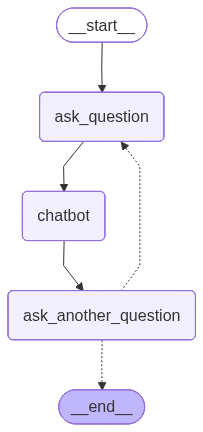

In [141]:
compiled_graph

In [142]:
config = {"configurable": {"thread_id": "1"}}

# First invoke: graph pauses at ask_question interrupt
result = compiled_graph.invoke(State(messages=[]), config)
print(result)

----> Ask question called:
What is your question?
{'messages': [], '__interrupt__': [Interrupt(value='What is your question?', id='668344f4bf5a6f96098008e1ac8e7367')]}


In [143]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="How old is the Statue of Liberty?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
Would you like to ask another question (yes/no)?


In [144]:
result = compiled_graph.invoke(Command(resume="yes"), config)
print(result)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
Would you like to ask another question (yes/no)?
----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
================================== Ai Message ==================================

Would you

In [145]:
result = compiled_graph.invoke(Command(resume="Who built the Statue of Liberty?"), config)
print(result)

----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statu

In [146]:
result = compiled_graph.invoke(Command(resume="yes"), config)
print(result)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who built the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was designed by **Frédéri

In [147]:
result = compiled_graph.invoke(Command(resume="Where was the Statue of Liberty built?"), config)
print(result)

----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who built the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was designed by **Frédéric August

In [148]:
result = compiled_graph.invoke(Command(resume="no"), config)
print(result)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

How old is the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886, so as of 2026 it is **139 years old**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who built the Statue of Liberty?
================================== Ai Message ==================================

The Statue of Liberty was designed by **Frédéri

### The `MessageState` class

In [151]:
from collections.abc import Sequence
from dotenv import load_dotenv
from typing import Annotated, Literal

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import add_messages, END, MessagesState, START, StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

We won't define a `State` class. Instead, we will change this class for the `MessagesState` class

In [152]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=42,
    temperature=0.5,
    max_completion_tokens=500,
)

In [153]:
# ask_question now uses interrupt(), so we test it through the graph instead
def ask_question(state: MessagesState) -> MessagesState:

    print("----> Ask question called:")

    for message in state.get("messages"):
        message.pretty_print()

    question = "What is your question?"
    print(question)

    question_interrupt = interrupt(question)

    return MessagesState(messages=[AIMessage(content=question), HumanMessage(content=question_interrupt)])

In [154]:
def chatbot(state: MessagesState) -> MessagesState:

    print(f"----> Chatbot called:")

    for message in state.get("messages"):
        message.pretty_print()

    response = chat.invoke(state.get("messages"))
    response.pretty_print()

    return MessagesState(messages=[response])

In [155]:
# ask_another_question now uses interrupt(), so we test it through the graph instead
def ask_another_question(state: MessagesState) -> MessagesState:

    print("----> Ask another question called:")

    for message in state.get("messages"):
        message.pretty_print()

    question = "Would you like to ask another question (yes/no)?"
    print(question)

    answer = interrupt(question)

    return MessagesState(messages=[AIMessage(content=question), HumanMessage(content=answer)])

In [156]:
def routing_function(state: MessagesState) -> Literal["ask_question", "__end__"]:

    if state.get("messages")[-1].content == "yes":
        return "ask_question"
    else:
        return "__end__"

In [161]:
graph = StateGraph(state_schema=MessagesState)
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
)

checkpointer = MemorySaver()
compiled_graph = graph.compile(checkpointer=checkpointer)

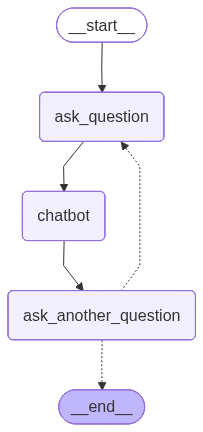

In [162]:
compiled_graph

In [163]:
config = {"configurable": {"thread_id": "1"}}

# First invoke: graph pauses at ask_question interrupt
result = compiled_graph.invoke(MessagesState(messages=[]), config)
print(result)

----> Ask question called:
What is your question?
{'messages': [], '__interrupt__': [Interrupt(value='What is your question?', id='4678680c64f35a046909f132ce6b9bce')]}


In [164]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="Where were The Beatles formed?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
Would you like to ask another question (yes/no)?


In [165]:
result = compiled_graph.invoke(Command(resume="yes"), config)
print(result)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
Would you like to ask another question (yes/no)?
----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =========

In [166]:
result = compiled_graph.invoke(Command(resume="When were The Beatles formed?"), config)
print(result)

----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
=========

In [167]:
result = compiled_graph.invoke(Command(resume="yes"), config)
print(result)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

When were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **1960**.
Would you like to ask another question (yes/no)?
----> Ask qu

In [168]:
result = compiled_graph.invoke(Command(resume="What was the first album by The Beatles?"), config)
print(result)

----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

When were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **1960**.
================================== Ai Message =======================

### Trimming Messages with the `RemoveMessage` class

Leave only the last 5 messages from the conversation before passing to the `ask_question` node

In [ ]:
from dotenv import load_dotenv
from typing import Literal

from langchain_core.messages import AIMessage, HumanMessage, RemoveMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import add_messages, END, MessagesState, START, StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

In [172]:
my_list = add_messages(
    [
        AIMessage(content="What is your question?"),
        HumanMessage(content="When were The Beatles formed?"),
        AIMessage(content="The Beatles were formed in **Liverpool, England**."),
        AIMessage(content="Would you like to ask another question (yes/no)?"),
        HumanMessage(content="yes"),
        AIMessage(content="What is your question?"),
        HumanMessage(content="What was the first album by The Beatles?"),
        AIMessage(content="The first album by The Beatles was 'Please Please Me'."),
        AIMessage(content="Would you like to ask another question (yes/no)?"),
    ],
    [
        HumanMessage(content="yes"),
    ]
)

In [173]:
my_list

[AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='a6e866c8-d7a9-411c-a8d4-88f8b2e17933', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='When were The Beatles formed?', additional_kwargs={}, response_metadata={}, id='1034452a-dcd3-470b-8ef3-ea053b6dfe21'),
 AIMessage(content='The Beatles were formed in **Liverpool, England**.', additional_kwargs={}, response_metadata={}, id='d1fe00a6-1391-4449-a23c-131fdf3280fd', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Would you like to ask another question (yes/no)?', additional_kwargs={}, response_metadata={}, id='c72f9d48-5073-4efc-b902-777ff89d821c', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='4ac41f15-8129-4a07-a77d-ba63173a4e58'),
 AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='360e12b1-03c0-4819-94dc-3abc49c8278f', tool_calls=[], invalid_tool_calls=[]),
 H

In [175]:
remove_messages = [RemoveMessage(id=message.id) for message in my_list[:-5]]
remove_messages

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='a6e866c8-d7a9-411c-a8d4-88f8b2e17933'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1034452a-dcd3-470b-8ef3-ea053b6dfe21'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='d1fe00a6-1391-4449-a23c-131fdf3280fd'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='c72f9d48-5073-4efc-b902-777ff89d821c'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='4ac41f15-8129-4a07-a77d-ba63173a4e58')]

In [176]:
add_messages(
    my_list,
    remove_messages,
)

[AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='360e12b1-03c0-4819-94dc-3abc49c8278f', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What was the first album by The Beatles?', additional_kwargs={}, response_metadata={}, id='9fd67ff5-bb25-4d3b-ac6c-177775f9988c'),
 AIMessage(content="The first album by The Beatles was 'Please Please Me'.", additional_kwargs={}, response_metadata={}, id='fd6490d7-2f64-4f96-86fb-037920de75d3', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Would you like to ask another question (yes/no)?', additional_kwargs={}, response_metadata={}, id='8e0c88d5-e8c2-4b1e-b8e0-37aaab40cd78', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='d5beba2b-c536-44b8-b782-49107dcf2294')]

Add the `trim_messages` node:

In [177]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=42,
    temperature=0.5,
    max_completion_tokens=500,
)

In [178]:
# ask_question now uses interrupt(), so we test it through the graph instead
def ask_question(state: MessagesState) -> MessagesState:

    print("----> Ask question called:")

    for message in state.get("messages"):
        message.pretty_print()

    question = "What is your question?"
    print(question)

    question_interrupt = interrupt(question)

    return MessagesState(messages=[AIMessage(content=question), HumanMessage(content=question_interrupt)])

In [179]:
def chatbot(state: MessagesState) -> MessagesState:

    print(f"----> Chatbot called:")

    for message in state.get("messages"):
        message.pretty_print()

    response = chat.invoke(state.get("messages"))
    response.pretty_print()

    return MessagesState(messages=[response])

In [180]:
# ask_another_question now uses interrupt(), so we test it through the graph instead
def ask_another_question(state: MessagesState) -> MessagesState:

    print("----> Ask another question called:")

    for message in state.get("messages"):
        message.pretty_print()

    question = "Would you like to ask another question (yes/no)?"
    print(question)

    answer = interrupt(question)

    return MessagesState(messages=[AIMessage(content=question), HumanMessage(content=answer)])

In [181]:
def trim_messages(state: MessagesState) -> MessagesState:

    print("----> Trim messages called:")

    remove_messages = [RemoveMessage(id=message.id) for message in state.get("messages")[:-5]]

    return MessagesState(messages=remove_messages)

In [182]:
def routing_function(state: MessagesState) -> Literal["trim_messages", "__end__"]:

    if state.get("messages")[-1].content == "yes":
        return "trim_messages"
    else:
        return "__end__"

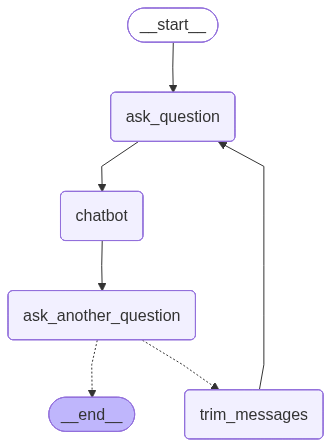

In [188]:
graph = StateGraph(state_schema=MessagesState)
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
)
graph.add_edge(start_key="trim_messages", end_key="ask_question")

checkpointer = MemorySaver()
compiled_graph = graph.compile(checkpointer=checkpointer)
compiled_graph

In [189]:
config = {"configurable": {"thread_id": "1"}}

# First invoke: graph pauses at ask_question interrupt
result = compiled_graph.invoke(MessagesState(messages=[]), config)
print(result)

----> Ask question called:
What is your question?
{'messages': [], '__interrupt__': [Interrupt(value='What is your question?', id='651299b0e9497412872b27422a62ab4e')]}


In [190]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="Where were The Beatles formed?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
Would you like to ask another question (yes/no)?


In [191]:
result = compiled_graph.invoke(Command(resume="yes"), config)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
Would you like to ask another question (yes/no)?
----> Trim messages called:
----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
============================

In [192]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="What was the first album by The Beatles?"), config)

----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
=========

In [193]:
result = compiled_graph.invoke(Command(resume="yes"), config)

----> Ask another question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What was the first album by The Beatles?
================================== Ai Message ==================================

The Beatles’ first studio album was **_Please Please Me_**, released in **1963**.
Would

In [194]:
result = compiled_graph.invoke(Command(resume="When did they split up?"), config)

----> Ask question called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What was the first album by The Beatles?
================================== Ai Message ==================================

The Beatles’ first studio album was **_Please Please Me_**, released in **1963**.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

yes
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What was the first album by The Beatles?
================================== Ai Message ==================================

The Beatl

### Summarising Messages

We'll replace the `trim_messages` node for one that summarises the conversation so far and deletes all the messages.

* The summarised conversation is kept in state using `State(MessageState)`

In [195]:
from dotenv import load_dotenv
from typing import Literal

from langchain_core.messages import (
    AIMessage, 
    HumanMessage, 
    RemoveMessage, 
    SystemMessage
)
from langchain_openai import ChatOpenAI
from langgraph.graph import END, MessagesState, START, StateGraph
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

Define the state:

In [197]:
class State(MessagesState):
    summary: str # Not Annotated, as we will replace the summary in the state

In [199]:
test_state = State()
bool(test_state.get("summary", ""))

False

In [200]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=42,
    temperature=0.5,
    max_completion_tokens=500,
)

In [201]:
# ask_question now uses interrupt(), so we test it through the graph instead
def ask_question(state: State) -> State:

    print("----> Ask question called:")

    ai_question = "What is your question?"
    print(ai_question)

    user_question = interrupt(ai_question)

    return State(messages=[AIMessage(content=ai_question), HumanMessage(content=user_question)])

In [217]:
def chatbot(state: State) -> State:

    print(f"----> Chatbot called:")

    for message in state.get("messages"):
        message.pretty_print()

    system_message = f"""
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}

    Keep this in mind when responding to the user's question.
    """

    response = chat.invoke([SystemMessage(content=system_message)] + state.get("messages"))
    response.pretty_print()

    return State(messages=[response])

In [218]:
# ask_another_question now uses interrupt(), so we test it through the graph instead
def ask_another_question(state: State) -> State:

    print("----> Ask another question called:")

    ai_question = "Would you like to ask another question (yes/no)?"
    print(ai_question)

    user_question = interrupt(ai_question)

    return State(messages=[AIMessage(content=ai_question), HumanMessage(content=user_question)])

In [230]:
def summarise_and_delete_messages(state: State) -> State:

    print("----> Summarise and delete messages called:")

    new_conversation = ""
    for message in state.get("messages"):
        new_conversation += f"{message.type}: {message.content}\n\n"

    summary_instructions = f"""
    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    {state.get("summary", "")}

    Here is the new conversation:
    {new_conversation}
    """

    print(summary_instructions)

    summary = chat.invoke([HumanMessage(content=summary_instructions)])

    print("Summary so far:",  summary.content)

    remove_messages = [RemoveMessage(id=message.id) for message in state.get("messages")[:]]

    return State(messages=remove_messages, summary=summary.content)

In [220]:
def routing_function(state: State) -> Literal["summarise_and_delete_messages", "__end__"]:

    if state.get("messages")[-1].content == "yes":
        return "summarise_and_delete_messages"
    else:
        return "__end__"

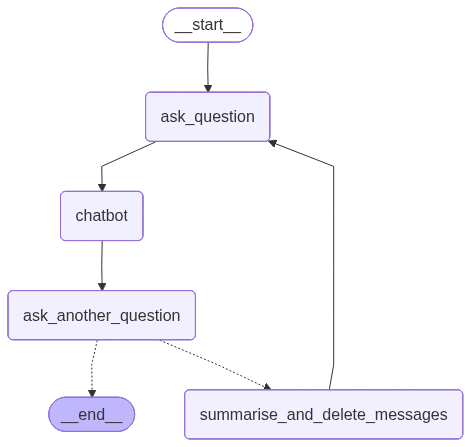

In [231]:
graph = StateGraph(state_schema=State)
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarise_and_delete_messages", summarise_and_delete_messages)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
)
graph.add_edge(start_key="summarise_and_delete_messages", end_key="ask_question")

checkpointer = MemorySaver()
compiled_graph = graph.compile(checkpointer=checkpointer)
compiled_graph

In [232]:
config = {"configurable": {"thread_id": "1"}}

# First invoke: graph pauses at ask_question interrupt
result = compiled_graph.invoke(MessagesState(messages=[]), config)
print(result)

----> Ask question called:
What is your question?
{'messages': [], '__interrupt__': [Interrupt(value='What is your question?', id='e228c2ce67dcb3537e8102c55e1b6ba8')]}


In [233]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="Where were The Beatles formed?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where were The Beatles formed?
================================== Ai Message ==================================

The Beatles were formed in **Liverpool, England**.
----> Ask another question called:
Would you like to ask another question (yes/no)?


In [234]:
# Resume with the question -> graph runs ask_question, chatbot, then pauses at ask_another_question
result = compiled_graph.invoke(Command(resume="yes"), config)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    

    Here is the new conversation:
    ai: What is your question?

human: Where were The Beatles formed?

ai: The Beatles were formed in **Liverpool, England**.

ai: Would you like to ask another question (yes/no)?

human: yes


    
Summary so far: The conversation so far is a simple Q&A. The user asked where The Beatles were formed, and the answer given was Liverpool, England. The assistant then asked if the user wanted another question, and the user replied “yes,” indicating the conversation is continuing and a new question is expected next.
----> Ask question called:
What is your question?


In [235]:
result = compiled_graph.invoke(Command(resume="When did they split up?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

When did they split up?
================================== Ai Message ==================================

The Beatles officially split up in 1970.
----> Ask another question called:
Would you like to ask another question (yes/no)?


In [236]:
result = compiled_graph.invoke(Command(resume="yes"), config)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    The conversation so far is a simple Q&A. The user asked where The Beatles were formed, and the answer given was Liverpool, England. The assistant then asked if the user wanted another question, and the user replied “yes,” indicating the conversation is continuing and a new question is expected next.

    Here is the new conversation:
    ai: What is your question?

human: When did they split up?

ai: The Beatles officially split up in 1970.

ai: Would you like to ask another question (yes/no)?

human: yes


    
Summary so far: The conversation remains a simple Q&A. After confirming they wanted another q

In [237]:
result = compiled_graph.invoke(Command(resume="What was the first album by The Beatles?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What was the first album by The Beatles?
================================== Ai Message ==================================

The Beatles’ first studio album was **_Please Please Me_**, released in **1963**.
----> Ask another question called:
Would you like to ask another question (yes/no)?


In [238]:
result = compiled_graph.invoke(Command(resume="yes"), config)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    The conversation remains a simple Q&A. After confirming they wanted another question, the user asked when The Beatles split up, and the answer given was that they officially split up in 1970. The assistant then asked whether the user wanted to ask another question, and the user replied “yes,” so the exchange is continuing with another question expected next.

    Here is the new conversation:
    ai: What is your question?

human: What was the first album by The Beatles?

ai: The Beatles’ first studio album was **_Please Please Me_**, released in **1963**.

ai: Would you like to ask another question (yes

In [239]:
result = compiled_graph.invoke(Command(resume="What questions have I asked you so far?"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What questions have I asked you so far?
================================== Ai Message ==================================

So far, you’ve asked:

1. **When did The Beatles split up?**
2. **What was their first album?**
3. **What questions have I asked you so far?**

If you want, I can also summarize the answers you got to each one.
----> Ask another question called:
Would you like to ask another question (yes/no)?


In [240]:
result = compiled_graph.invoke(Command(resume="yes"), config)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    The conversation is still a simple Q&A about The Beatles. After the previous exchange about when the band split up, the user asked what their first album was, and the assistant replied that their first studio album was *Please Please Me*, released in 1963. The assistant then asked if the user wanted to ask another question, and the user answered “yes,” so the conversation is continuing with another question expected next.

    Here is the new conversation:
    ai: What is your question?

human: What questions have I asked you so far?

ai: So far, you’ve asked:

1. **When did The Beatles split up?**
2. **

In [241]:
result = compiled_graph.invoke(Command(resume="Provide the details of their last album"), config)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Provide the details of their last album
================================== Ai Message ==================================

The Beatles’ last released album was **Let It Be**, released on **8 May 1970**.

A few key details:
- **Recorded:** Mostly in **January 1969**
- **Original concept:** It began as the **“Get Back”** project, meant to capture the band rehearsing and performing more naturally
- **Produced by:** Primarily **George Martin**, with later production work by **Phil Spector**
- **Notable songs:** “Let It Be,” “Get Back,” “Across the Universe,” “The Long and Winding Road,” and “I Me Mine”

If you want, I can also give you the details of their **last recorded album** versus their **last released album**, since those are not

In [242]:
result = compiled_graph.invoke(Command(resume="no"), config)

----> Ask another question called:
Would you like to ask another question (yes/no)?


## Thread-Level Persistence

### Checkpointers and Threads

A **Checkpointer** in LangGraph is a component tha tsaves the state of the graph after each node execution within a super-step.

* A super-step are nodes at the same horizontal level (i.e., those that can be executed in parallel)

* The saved information and additional metadata are stored in a LangGraph object called `StateSnapshot`

* These `StateSnapshot` objects enable human-in-the-loop flows for testing, debugging or manually directing an agent

A **Thread** is a collection of related checkpoints:

* Each Thread is identified by a Thread ID, which allows LangGraph to track the progression of different conversations

* If a Graph is invoked with a Thread ID corresponding to a previous conversation, then the last checkpoint from that Thread becomes the input state for the next run

* Threads provide continity and give conversational agents memory over time: **Short-term** and **Long-term** memory:

    - **Short-term**: Thread-scope memory: 

        * Remembers interactions within a single thread

        * Resets when the kernel is restarted

        * Resets when the system is shut down

    - **Long-term**: 

        * Persists beyond the lifetime of a single session

        * Backed by external storage (databases)

        * Allows the Graph to retrieve relevant past information dynamically based on the context

**Important**: Because the `input()` method doesn't work in Jupyter Notebooks in Cursor/VSCode, I have been using the Checkpointers and the `langgraph.checkpoint.memory.MemorySaver` class throughout this notebook

### The `StateSnapshot` class

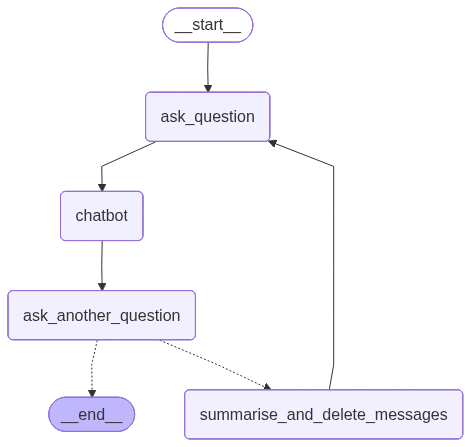

In [243]:
compiled_graph

In [ ]:
graph_states = compiled_graph.get_state_history(config) # graph_states is a generator object

In [ ]:
graph_states_list = [state for state in graph_states]
for state in graph_states_list:
    print(state) 
    print("-"*100)
# The first state is the last conversation

StateSnapshot(values={'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='c66335b9-54f2-40d4-a08d-7743416b2b71', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Provide the details of their last album', additional_kwargs={}, response_metadata={}, id='9c74c031-c384-43ed-914c-074b99026e79'), AIMessage(content='The Beatles’ last released album was **Let It Be**, released on **8 May 1970**.\n\nA few key details:\n- **Recorded:** Mostly in **January 1969**\n- **Original concept:** It began as the **“Get Back”** project, meant to capture the band rehearsing and performing more naturally\n- **Produced by:** Primarily **George Martin**, with later production work by **Phil Spector**\n- **Notable songs:** “Let It Be,” “Get Back,” “Across the Universe,” “The Long and Winding Road,” and “I Me Mine”\n\nIf you want, I can also give you the details of their **last recorded album** versus their **last released album**, since those are 

In [250]:
# Reverse the order of the states
for state in graph_states_list[::-1]:
    print(f"""
    Step: {state.metadata.get("step")}
    Summary: {state.values.get("summary", "")}
    Next: {state.next}
    Messages:
    """)
    for message in state.values.get("messages"):
        print(message.pretty_print())
    print("-"*100)


    Step: -1
    Summary: 
    Next: ('__start__',)
    Messages:
    
----------------------------------------------------------------------------------------------------

    Step: 0
    Summary: 
    Next: ('ask_question',)
    Messages:
    
----------------------------------------------------------------------------------------------------

    Step: 1
    Summary: 
    Next: ('chatbot',)
    Messages:
    
================================== Ai Message ==================================

What is your question?
None
================================ Human Message =================================

Where were The Beatles formed?
None
----------------------------------------------------------------------------------------------------

    Step: 2
    Summary: 
    Next: ('ask_another_question',)
    Messages:
    
================================== Ai Message ==================================

What is your question?
None
================================ Human Message ===============

### Long-term Memory with SQLite

Storing checkpoints in a local database using SQLite

In [17]:
import sqlite3

from dotenv import load_dotenv
from typing import Literal

from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    RemoveMessage,
    SystemMessage
)
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt, Command


load_dotenv()


True

**Define the State**:

In [2]:
class State(MessagesState):
    summary: str

**Define the nodes**:

In [3]:
chat = ChatOpenAI(
    model="gpt-5.4-mini",
    seed=42,
    temperature=0.5,
    max_completion_tokens=500,
)

In [4]:
# ask_question now uses interrupt(), so we test it through the graph instead
def ask_question(state: State) -> State:

    print("----> Ask question called:")

    ai_question = "What is your question?"
    print(ai_question)

    user_question = interrupt(ai_question)

    return State(messages=[AIMessage(content=ai_question), HumanMessage(content=user_question)])

In [5]:
def chatbot(state: State) -> State:

    print(f"----> Chatbot called:")

    for message in state.get("messages"):
        message.pretty_print()

    system_message = f"""
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}

    Keep this in mind when responding to the user's question.
    """

    response = chat.invoke([SystemMessage(content=system_message)] + state.get("messages"))
    response.pretty_print()

    return State(messages=[response])

In [6]:
# ask_another_question now uses interrupt(), so we test it through the graph instead
def ask_another_question(state: State) -> State:

    print("----> Ask another question called:")

    ai_question = "Would you like to ask another question (yes/no)?"
    print(ai_question)

    user_question = interrupt(ai_question)

    return State(messages=[AIMessage(content=ai_question), HumanMessage(content=user_question)])

In [7]:
def summarise_and_delete_messages(state: State) -> State:

    print("----> Summarise and delete messages called:")

    new_conversation = ""
    for message in state.get("messages"):
        new_conversation += f"{message.type}: {message.content}\n\n"

    summary_instructions = f"""
    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    {state.get("summary", "")}

    Here is the new conversation:
    {new_conversation}
    """

    print(summary_instructions)

    summary = chat.invoke([HumanMessage(content=summary_instructions)])

    print("Summary so far:",  summary.content)

    remove_messages = [RemoveMessage(id=message.id) for message in state.get("messages")[:]]

    return State(messages=remove_messages, summary=summary.content)

In [10]:
def routing_function(state: State) -> Literal["summarise_and_delete_messages", "__end__"]:

    if state.get("messages")[-1].content == "yes":
        return "summarise_and_delete_messages"
    else:
        return "__end__"

**Define the Graph**:

In [11]:
graph = StateGraph(state_schema=State)
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarise_and_delete_messages", summarise_and_delete_messages)

graph.add_edge(start_key=START, end_key="ask_question")
graph.add_edge(start_key="ask_question", end_key="chatbot")
graph.add_edge(start_key="chatbot", end_key="ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
)
graph.add_edge(start_key="summarise_and_delete_messages", end_key="ask_question")

**Create a SQLite database**:

In [12]:
db_path = "sqlite_database/langgraph_checkpoint.db"

connection = sqlite3.connect(database=db_path, check_same_thread=False)

**Point the checkpointer to the SQLite database**:

In [13]:
checkpointer = SqliteSaver(conn=connection)

**Compile and show Graph**:

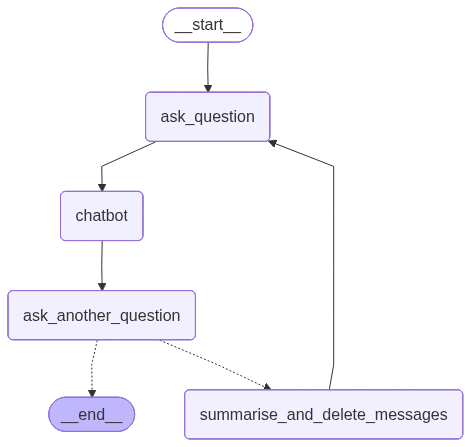

In [14]:
compiled_graph = graph.compile(checkpointer=checkpointer)
compiled_graph

**Configure thread ID and invoke the compiled_graph**:

In [15]:
config1 = {"configurable": {"thread_id": "1"}}
config2 = {"configurable": {"thread_id": "2"}}

In [27]:
compiled_graph.invoke(State(), config1)

----> Ask question called:
What is your question?


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='f0c70144-fcf1-4452-b9c6-4da749847fa8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What about the creator of the programming language I mentioned before?', additional_kwargs={}, response_metadata={}, id='5e9904c8-83bc-4bf9-affb-8bda497f2d83'),
  AIMessage(content='If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.\n\nIf you meant a different programming language, tell me which one and I’ll identify the creator.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 164, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mo

In [28]:
compiled_graph.invoke(Command(resume="Who is the creator of the Python programming language?"), config1)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What about the creator of the programming language I mentioned before?
================================== Ai Message ==================================

If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.

If you meant a different programming language, tell me which one and I’ll identify the creator.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

Where was he born?
================================== Ai Message ==================================

What is your question?
======================

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='f0c70144-fcf1-4452-b9c6-4da749847fa8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What about the creator of the programming language I mentioned before?', additional_kwargs={}, response_metadata={}, id='5e9904c8-83bc-4bf9-affb-8bda497f2d83'),
  AIMessage(content='If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.\n\nIf you meant a different programming language, tell me which one and I’ll identify the creator.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 164, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mo

In [268]:
result = compiled_graph.invoke(Command(resume="yes"), config1)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    

    Here is the new conversation:
    ai: What is your question?

human: Who is the creator of the Python programming language?

ai: The creator of Python is **Guido van Rossum**.

ai: Would you like to ask another question (yes/no)?

human: yes


    
Summary so far: The conversation so far was a simple Q&A exchange. The user asked who created the Python programming language, and the assistant answered that it was Guido van Rossum. The assistant then asked whether the user would like to ask another question, and the user replied “yes,” indicating the conversation is likely to continue with another que

In [269]:
result = compiled_graph.invoke(Command(resume="Who are the creators of the LangChain and LangGraph libraries?"), config1)


----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Who are the creators of the LangChain and LangGraph libraries?
================================== Ai Message ==================================

**LangChain** was created by **Harrison Chase**.

**LangGraph** was created by the **LangChain team** at **LangChain, Inc.**, with Harrison Chase as a key founder and leader.
----> Ask another question called:
Would you like to ask another question (yes/no)?


In [270]:
result = compiled_graph.invoke(Command(resume="yes"), config1)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    The conversation so far was a simple Q&A exchange. The user asked who created the Python programming language, and the assistant answered that it was Guido van Rossum. The assistant then asked whether the user would like to ask another question, and the user replied “yes,” indicating the conversation is likely to continue with another query.

    Here is the new conversation:
    ai: What is your question?

human: Who are the creators of the LangChain and LangGraph libraries?

ai: **LangChain** was created by **Harrison Chase**.

**LangGraph** was created by the **LangChain team** at **LangChain, Inc.**,

In [271]:
result = compiled_graph.invoke(Command(resume="Are they software engineers?"), config1)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Are they software engineers?
================================== Ai Message ==================================

Yes — Harrison Chase is a software engineer, and the LangChain/LangGraph team at LangChain, Inc. is made up of software engineers and related technical roles.

If you want, I can also tell you more about their backgrounds.
----> Ask another question called:
Would you like to ask another question (yes/no)?


In [272]:
result = compiled_graph.invoke(Command(resume="yes"), config1)

----> Ask another question called:
Would you like to ask another question (yes/no)?
----> Summarise and delete messages called:

    Update the ongoing summary by incorporating the new lines of conversation below.
    Build upon the previous summary rather than repeating it so that the result 
    reflects the most recent context and developments.

    Here is the previous summary:
    The conversation continued as a brief Q&A. The user asked who created the LangChain and LangGraph libraries, and the assistant answered that LangChain was created by Harrison Chase, while LangGraph was created by the LangChain team at LangChain, Inc., with Harrison Chase as a key founder and leader. The assistant then asked whether the user would like to ask another question, and the user replied “yes,” indicating the conversation will likely continue with another query.

    Here is the new conversation:
    ai: What is your question?

human: Are they software engineers?

ai: Yes — Harrison Chase is a s

In [273]:
result = compiled_graph.invoke(Command(resume="What about the creator of the programming language I mentioned before?"), config1)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What about the creator of the programming language I mentioned before?
================================== Ai Message ==================================

If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.

If you meant a different programming language, tell me which one and I’ll identify the creator.
----> Ask another question called:
Would you like to ask another question (yes/no)?


After restarting the kernel and re-running all cells until the compilation of the Graph ...

In [18]:
result = compiled_graph.invoke(Command(resume="Where was he born?"), config1)

----> Ask another question called:
Would you like to ask another question (yes/no)?


In [19]:
result = compiled_graph.invoke(Command(resume="yes"), config1)

In [21]:
compiled_graph.invoke(Command(resume="yes"), config1)

----> Ask question called:
What is your question?
----> Chatbot called:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What about the creator of the programming language I mentioned before?
================================== Ai Message ==================================

If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.

If you meant a different programming language, tell me which one and I’ll identify the creator.
================================== Ai Message ==================================

Would you like to ask another question (yes/no)?
================================ Human Message =================================

Where was he born?
================================== Ai Message ==================================

What is your question?
======================

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='f0c70144-fcf1-4452-b9c6-4da749847fa8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What about the creator of the programming language I mentioned before?', additional_kwargs={}, response_metadata={}, id='5e9904c8-83bc-4bf9-affb-8bda497f2d83'),
  AIMessage(content='If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.\n\nIf you meant a different programming language, tell me which one and I’ll identify the creator.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 164, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mo

In [25]:
compiled_graph.invoke(Command(resume="yes"), config1)

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='f0c70144-fcf1-4452-b9c6-4da749847fa8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What about the creator of the programming language I mentioned before?', additional_kwargs={}, response_metadata={}, id='5e9904c8-83bc-4bf9-affb-8bda497f2d83'),
  AIMessage(content='If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.\n\nIf you meant a different programming language, tell me which one and I’ll identify the creator.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 164, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mo

In [24]:
compiled_graph.invoke(Command(resume="where was he born?"), config1)

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='f0c70144-fcf1-4452-b9c6-4da749847fa8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What about the creator of the programming language I mentioned before?', additional_kwargs={}, response_metadata={}, id='5e9904c8-83bc-4bf9-affb-8bda497f2d83'),
  AIMessage(content='If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.\n\nIf you meant a different programming language, tell me which one and I’ll identify the creator.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 164, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mo

In [26]:
compiled_graph.invoke(Command(resume="yes"), config1)

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='f0c70144-fcf1-4452-b9c6-4da749847fa8', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What about the creator of the programming language I mentioned before?', additional_kwargs={}, response_metadata={}, id='5e9904c8-83bc-4bf9-affb-8bda497f2d83'),
  AIMessage(content='If you mean the creator of **Python**, that’s **Guido van Rossum** — he’s primarily a **software engineer** and computer scientist.\n\nIf you meant a different programming language, tell me which one and I’ll identify the creator.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 164, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'mo